# Bilby Tutorial 

This is a brief tutorial on using Bilby to plot waveforms and perform parameter estimation. 

Bilby is the Bayesian inference library used by the LVK Collaboration and the wider community to analyze LVK data.

The documentation for Bilby can be found <a href = "https://bilby-dev.github.io/bilby/index.html"> here </a>.

Other good resources are <a href = "https://arxiv.org/pdf/1811.02042">this</a> paper by Ashton et al. and <a href = "https://arxiv.org/pdf/2006.00714">this</a> one by Romero-Shaw et al. 

You will need to pip install matplotlib, numpy, bilby, and jupyter.

Download this file and move it to whatever directory you want to work in. 

Navigate to that directory with your terminal and run "jupyter notebook"

This will open a browser window, from which you can open the notebook. 

Find documentation on Jupyter <a href = "https://jupyter.org/install"> here</a>. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import bilby 
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
# Specify the output directory and the label for the run.
outdir = "outdir"
label = "CFCGWA_tutorial"
bilby.core.utils.setup_logger(outdir=outdir, label=label,log_level= "warning")

# Plotting Waveforms

We will begin by plotting the waveform in both the time and frequency domains.

In [5]:
# this function produces frequency and time domain gravitational wave signals observed at LIGO Hanford, given binary parameters 
def plotting_data(parameters):
    
    sampling_frequency = 2048.0
    minimum_frequency = parameters["minimum_frequency"]
    
    duration = bilby.gw.detector.get_safe_signal_duration(
        parameters['mass_1'],
        parameters['mass_2'],
        parameters['a_1'],
        parameters['a_2'],
        parameters['tilt_1'],
        parameters['tilt_2'],
        flow=minimum_frequency)

    end_time = parameters["geocent_time"] + 2 # it is standard to include 2 seconds after the merger for the ringdown 
    start_time = end_time - duration 

    # Fixed arguments passed into the source model
    waveform_arguments = dict(
        waveform_approximant="IMRPhenomPv2",
        reference_frequency=50.0,
        minimum_frequency=minimum_frequency,
)

    # Create the waveform_generator using a LAL BinaryBlackHole source function
    waveform_generator = bilby.gw.WaveformGenerator(
        start_time = start_time,
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
        waveform_arguments=waveform_arguments,
    )

    ifo = bilby.gw.detector.InterferometerList(["H1"])

    ifo.set_strain_data_from_zero_noise( 
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=start_time,
    );
    
    ifo.inject_signal(
    waveform_generator=waveform_generator, parameters=parameters
);

    print("SNR: {}".format(total_snr(ifo)))
    
    mask = ifo[0].frequency_mask
    frequencies = ifo[0].frequency_array[mask]
    fd_strain = abs(ifo[0].frequency_domain_strain[mask])

    times = ifo[0].time_array - parameters["geocent_time"]
    td_strain = ifo[0].time_domain_strain

    ISCO = 4.4e+3/(parameters["mass_1"]+parameters["mass_2"])

    output_dict = dict(
        frequency_array = frequencies,
        hplus_fd = fd_strain,
        time_array = times,
        hplus_td = td_strain,
        ISCO = ISCO
    )
    
    return output_dict

# this computes the total SNR for a signal observed by multiple detectors. SNRs add in quadrature 
def total_snr(ifo_list):
    snr_sqrd = 0
    for ifo in ifo_list:
        snr_sqrd += np.real(ifo.optimal_snr_squared(ifo.frequency_domain_strain))
    return np.sqrt(snr_sqrd)

SNR: 57.45212057842871
SNR: 57.45212057842871


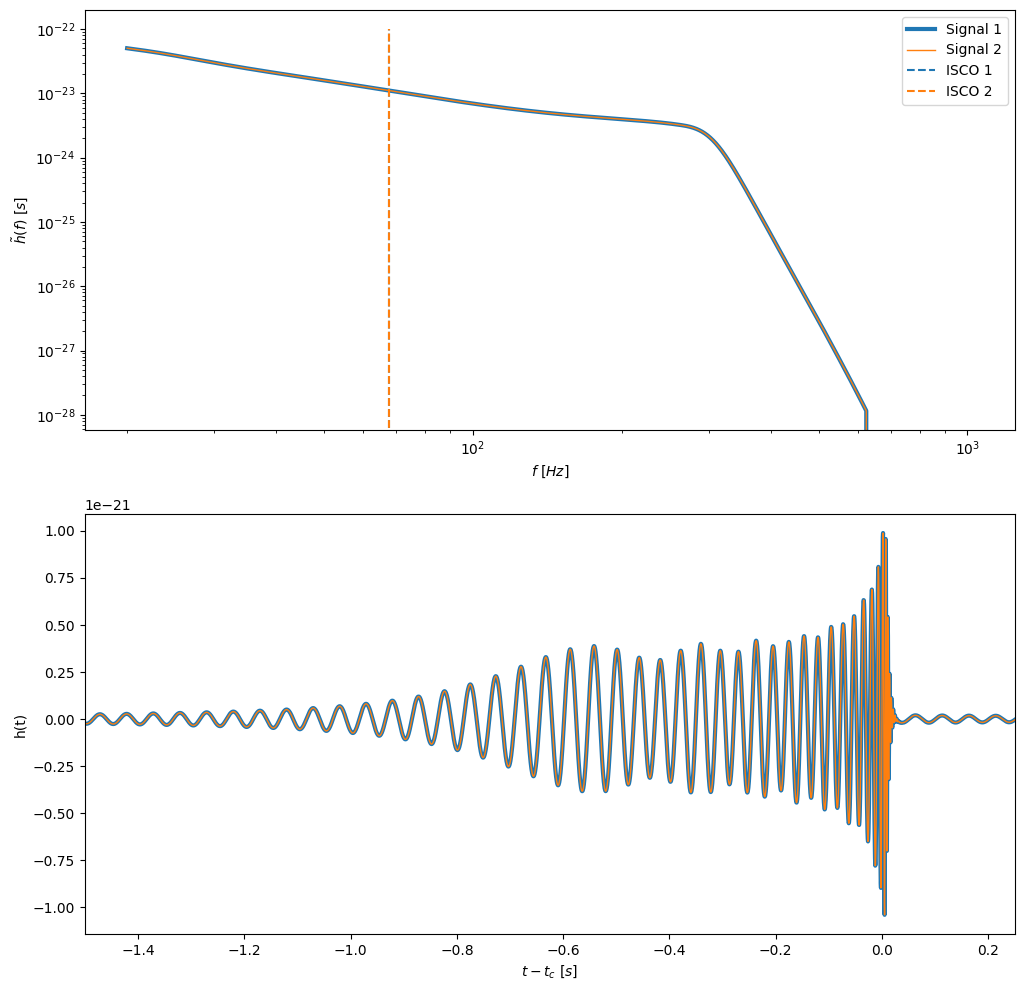

In [10]:
# one set of parameters
parameters_1 = dict(
    # two mass parameters 
    mass_1=36.0,
    mass_2=29.0, 
    # six angular momentum paramters 
    a_1=0.4,
    a_2=0.3, 
    tilt_1=0.5, 
    tilt_2=1.0, 
    phi_12=1.7,
    phi_jl=0.3, 
    # angle between total angular momenum and line of sight
    theta_jn=0.4,
    # three parameters to locate the binary in space 
    luminosity_distance=410,
    ra=1.375,
    dec=-1.2108,
    # polarization angle 
    psi=2.659,
    # phase at the reference frequency 
    phase=1.3,
    # time of merger 
    geocent_time=1126259642.413,
) 

parameters_1["minimum_frequency"]=20

# produce the signals  
plot_data_1 =plotting_data(parameters_1)

# Here we produce a second set of parameters identical to the first
# you can change one or more injection parameters below by overwriting the entry  
parameters_2 = parameters_1.copy()
parameters_2["luminosity_distance"]=410


plot_data_2=plotting_data(parameters_2)

# plot the waveforms 
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
axes[0].loglog(plot_data_1["frequency_array"],abs(plot_data_1["hplus_fd"]),label = "Signal 1",linewidth = 3)
axes[0].loglog(plot_data_2["frequency_array"],abs(plot_data_2["hplus_fd"]),label = "Signal 2",linewidth = 1)
axes[0].vlines(plot_data_1["ISCO"],0,1e-22,linestyle='--',color = "C0",label = "ISCO 1")
axes[0].vlines(plot_data_2["ISCO"],0,1e-22,linestyle='--',color = "C1",label = "ISCO 2")
axes[0].set_xlabel("$f~[Hz]$")
axes[0].set_ylabel("$\\tilde h(f) ~[s]$")
axes[0].legend()
axes[1].plot(plot_data_1["time_array"],plot_data_1["hplus_td"],linewidth = 3)
axes[1].plot(plot_data_2["time_array"],plot_data_2["hplus_td"],linewidth = 1)
axes[1].set_xlabel("$t - t_c~[s]$")
axes[1].set_ylabel("h(t)");
axes[1].set_xlim(-1.5,.25);

## Questions 

What happens when the total mass of the binary increases? Decreases?

What happens when you change the luminosity distance? How does SNR scale with luminosity distance?

What happens if you change the minimum frequency? What about the phase?

# Parameter Estimation 

In binary parameter estimation, we approximate the posterior probability distribution on the binary parameters given the observed data and a chosen waveform model. 

Bayes's theorem tells us that the posterior is 

$$P(\theta|d,h) = \frac{\mathcal{L}(d|\theta,h)\pi(\theta)}{\mathcal{Z}(d,h)}$$

$\theta$ is a vector containing all of the binary parameters, i.e. masses, spins, distance, etc..

$h=h(\theta)$ models the signal as a function of the binary parameters. 

The evidence $\mathcal{Z}(d,h)$ is the overall probability of observing $d$. For our purposes, it is a normalization factor, but it is also used in model selection. 

The prior $\pi(\theta)$ is a probability distribution that contains our assumptions about the parameters before the observation is made. 

The likelihood $\mathcal{L}(d|\theta,h)$ is the probability of observing $d$ given the $\theta$ and $h$. We choose the likelihood based on our assumptions about the data generation process and the noise model. We assume that an observed signal is the sum of detector noise $n$ and signal produced by the binary $h(\theta)$

$$d = n + h(\theta)\,.$$

For our current ground-based detectors, we assume that $n$ is stationary and Gaussian in the frequency domain, so the relevant likelihood is 

$$
\begin{align}
\mathcal{L}(d|\theta,h) \propto &~\exp \left[-\frac{1}{2}(n|n)\right]\\
\propto&~\exp \left[-\frac{1}{2}(d-h(\theta)|d-h(\theta)\right]
\end{align}$$

where 

 $$(a|b) = 4 \mathrm{Re} \int \frac{\tilde a(f) \tilde b^{*}(f)}{S_n(f)}df$$

is a noise-weighted inner product in the frequency domain, $S_n(f)$ is the power spectral density (PSD). 


To estimate the parameters, we stochastically sample from the binary posterior using methods such as Markov chain Monte Carlo (MCMC) or nested sampling. The result is a set of samples of $\theta$ that are distributed according to $P(\theta|d,h)$.


See 
<a href = "https://arxiv.org/pdf/1809.02293"> Talbot & Thrane </a> for a good overview of Bayesian parameter estimation in the context of gravitational waves. 

## Injection and Recovery 
Below is an example of an "injection and recovery": We construct, or inject, a synthetic gravitational wave signal, and then we attempt to recover the binary parameters. Because we know the parameters we started with, we can make sure our data analysis pipeline is working well before turning to real data. 

In [11]:
bilby.core.utils.setup_logger(outdir=outdir, label=label,)

In [13]:
parameters_1 = dict(
    # two mass parameters 
    mass_1=36.0,
    mass_2=29.0, 
    # six angular momentum paramters 
    a_1=0.4,
    a_2=0.3, 
    tilt_1=0.5, 
    tilt_2=1.0, 
    phi_12=1.7,
    phi_jl=0.3, 
    # angle between total angular momenum and line of sight
    theta_jn=0.4,
    # three parameters to locate the binary in space 
    luminosity_distance=410,
    ra=1.375,
    dec=-1.2108,
    # polarization angle 
    psi=2.659,
    # phase at the reference frequency 
    phase=1.3,
    # time of merger 
    geocent_time=1126259642.413,
) 



#These functions will be useful for converting between mass parameters 
def get_component_masses(parameters):
    converted_parameters = parameters.copy()
    converted_parameters["mass_1"],converted_parameters["mass_2"] = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(parameters['chirp_mass'], parameters['mass_ratio'])
    return converted_parameters

def get_chirp_mass_mass_ratio(parameters):
    converted_parameters = parameters.copy()
    converted_parameters["mass_ratio"] = bilby.gw.conversion.component_masses_to_mass_ratio(injection_parameters["mass_1"],injection_parameters["mass_2"])
    converted_parameters["chirp_mass"] = bilby.gw.conversion.component_masses_to_chirp_mass(injection_parameters["mass_1"],injection_parameters["mass_2"])
    return converted_parameters

# this isn't necessary, Bilby will convert component mass ratio to chirp mass/mass ratio for sampling
# but it will be useful for  us to have the injected values of these parameters
injection_parameters = get_chirp_mass_mass_ratio(injection_parameters)

In [14]:
sampling_frequency = 2048.0 # the maximum freqency is half the sampling frequency (so 1024 in this case).  
                            # 2048.0 Hz is good for most stellar mass binaries, but for lower mass signals,  you may want to increase to 4096 
minimum_frequency = 20 # 20 Hz is the standard minimum frequency cutoff for current gravitational wave observations 

# the signal duration rounded up to the nearest power of 2
duration = bilby.gw.detector.get_safe_signal_duration(
    injection_parameters['mass_1'],
    injection_parameters['mass_2'],
    injection_parameters['a_1'],
    injection_parameters['a_2'],
    injection_parameters['tilt_1'],
    injection_parameters['tilt_2'],
    flow=minimum_frequency)

end_time = injection_parameters["geocent_time"] + 2 # it is standard to include 2 seconds after the merger time for the ringdown 
start_time = end_time - duration 

## The Likelihood 

The likelihood depends on the data $d$ and our chosen model $h(\theta)$

$$
\begin{align}
P(d|\theta,h)\propto&~\exp \left[-\frac{1}{2}(d-h(\theta)|d-h(\theta)\right]
\end{align}$$

First, we set up the "WaveformGenerator" which contains info about $h(\theta)$

In [15]:
waveform_arguments = dict(
    waveform_approximant="IMRPhenomD", #this is the name of the waveform approximant 
    reference_frequency=50.0, # \phi(f_{ref}) = \phi_c = injection_parameters["phase"]
    minimum_frequency=minimum_frequency,
)

waveform_generator = bilby.gw.WaveformGenerator(
    start_time = start_time,
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
    )

16:10 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


Then, we set up the detectors and produce the signal $d$. 

An instance of the Interferometer class contains information about the detector, its location, and its power spectral density.

In [16]:
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
# H1 is LIGO Hanford, L1 is LIGO Livingston, V1 is Virgo, K1 is KAGRA 


## This sets up the data to have no noise. 
## We will start with this simplified case, but generally, you should inject your signal into noise 
ifos.set_strain_data_from_zero_noise( 
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=start_time,
);

# This function generates Gaussian noise from the PSD 
# Uncomment it and rerun the notebook to produce an injection with noise 
# ifos.set_strain_data_from_power_spectral_densities( 
#     sampling_frequency=sampling_frequency,
#     duration=duration,
#     start_time=start_time,
# );

## And this is where we inject the signal into the data. We assume that the signal is h(\theta). 
ifos.inject_signal(
    waveform_generator=waveform_generator, parameters=injection_parameters
);

16:11 bilby INFO    : Injected signal in H1:
16:11 bilby INFO    :   optimal SNR = 12.19
16:11 bilby INFO    :   matched filter SNR = 12.19-0.00j
16:11 bilby INFO    :   mass_1 = 50
16:11 bilby INFO    :   mass_2 = 30
16:11 bilby INFO    :   a_1 = 0.0
16:11 bilby INFO    :   a_2 = 0.0
16:11 bilby INFO    :   tilt_1 = 0.0
16:11 bilby INFO    :   tilt_2 = 0.0
16:11 bilby INFO    :   phi_12 = 0.0
16:11 bilby INFO    :   phi_jl = 0.0
16:11 bilby INFO    :   theta_jn = 0.4
16:11 bilby INFO    :   luminosity_distance = 2000
16:11 bilby INFO    :   ra = 1.375
16:11 bilby INFO    :   dec = -1.2108
16:11 bilby INFO    :   psi = 2.659
16:11 bilby INFO    :   phase = 1.3
16:11 bilby INFO    :   geocent_time = 1126259642.413
16:11 bilby INFO    :   mass_ratio = 0.6
16:11 bilby INFO    :   chirp_mass = 33.49937913311429
16:11 bilby INFO    : Injected signal in L1:
16:11 bilby INFO    :   optimal SNR = 9.87
16:11 bilby INFO    :   matched filter SNR = 9.87-0.00j
16:11 bilby INFO    :   mass_1 = 50
1

Below, we plot the signal in the time and frequency domains at each detector. Along with the amplitude spectral density (ASD), which is $\sqrt{S_n(f)}$

Rather than plotting  $|\tilde h(f)|$, we plot $2|\tilde h(f)|\sqrt{f}$ because the signal to noise ratio is

$$\rho^2 = (h|h) = 4 \mathrm{Re} \int \frac{\tilde h(f) \tilde h^{*}(f)}{S_n(f)}df$$

and compairing $2|\tilde h(f)|\sqrt{f}$ to $\sqrt{S_n(f)}$ allows us to (sort of) estimate the SNR by eye. 

Total SNR: 15.67878661464667


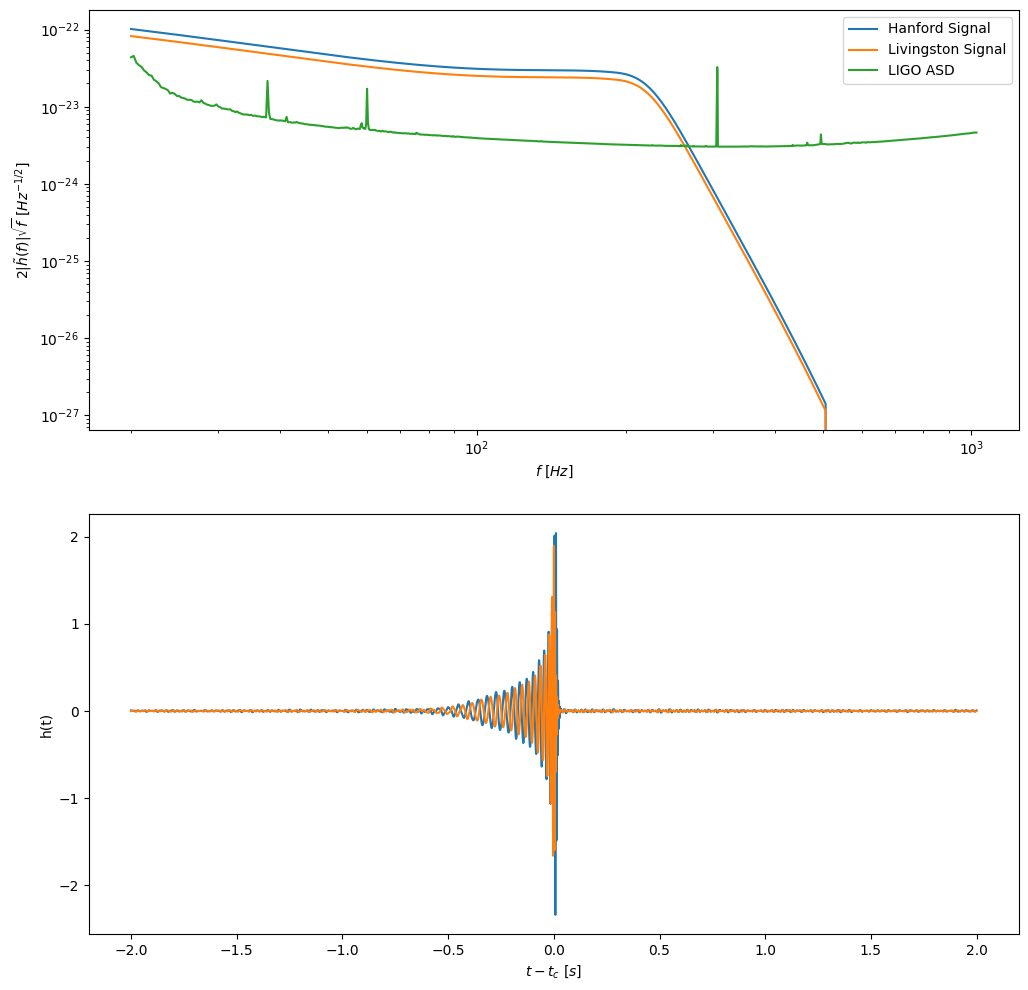

In [19]:
print("Total SNR: {}".format(total_snr(ifos)))

mask = ifos[0].frequency_mask # removes frequencies where there is no signal 
freqencies = ifos[0].frequency_array[mask]
fd_strain_h = ifos[0].frequency_domain_strain[mask]
fd_strain_l = ifos[1].frequency_domain_strain[mask]
asd =  ifos[0].amplitude_spectral_density_array[mask]

times = ifos[0].time_array - injection_parameters["geocent_time"]
td_strain_h = ifos[0].whitened_time_domain_strain
td_strain_l = ifos[1].whitened_time_domain_strain

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,12))
axes[0].loglog(freqencies,2*abs(fd_strain_h)*np.sqrt(freqencies),label = "Hanford Signal")
axes[0].loglog(freqencies,2*abs(fd_strain_l)*np.sqrt(freqencies),label = "Livingston Signal")
axes[0].loglog(freqencies,asd,label = "LIGO ASD")
axes[0].set_xlabel("$f~[Hz]$")
axes[0].set_ylabel("$2|\\tilde h(f)|\sqrt{f}~[Hz^{-1/2}]$")
axes[0].legend()
axes[1].plot(times,td_strain_h)
axes[1].plot(times,td_strain_l)
axes[1].set_xlabel("$t - t_c~[s]$")
axes[1].set_ylabel("h(t)");
#axes[1].set_xlim(-1.25,.25);

Finally, we define the likelihood. 

In [20]:
likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos, # this is the data  
    waveform_generator=waveform_generator # this is our model 
)
# We are currently using the same model and waveform generator that we used to produce the signal. 
# However, it is also possibl also possible to define a second waveform generator with different properties 

## The Priors

Bilby has default binary black hole priors, which are generally a good starting point, but you may need to overwrite some of them depending on what you are doing. They assume a uniform distribution on the component masses (with the restriction that $m_1$>$m_2$), but we sample on chirp mass $\mathcal{M}$ and mass ratio $q$. Bilby has built-in chirp mass and mass ratio priors for this configuration. 


For the sake of time, we don't want to sample on all 15 parameters, so we will set the priors on 13 of them to delta functions at their injection value. 

In [21]:
priors = bilby.gw.prior.BBHPriorDict()

non_sampled_parameters =[
    "a_1",
    "a_2",
    "tilt_1",
    "tilt_2",
    "phi_12",
    "phi_jl",
    "psi",
    "luminosity_distance",
    "theta_jn",
    "ra",
    "dec",
    "geocent_time",
    "phase",
]
# set the non-sampled parameter priors to delta functions 
for key in non_sampled_parameters:
    priors[key] = injection_parameters[key]
    
#display the priors below 
for key in priors.keys():
    print(key+": {}".format(str(priors[key])))

16:12 bilby INFO    : No prior given, using default BBH priors in /Users/cbo/Library/Python/3.11/lib/python/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.


mass_1: Constraint(minimum=5, maximum=100, name='mass_1', latex_label='$m_1$', unit=None)
mass_2: Constraint(minimum=5, maximum=100, name='mass_2', latex_label='$m_2$', unit=None)
mass_ratio: bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False)
chirp_mass: bilby.gw.prior.UniformInComponentsChirpMass(minimum=25, maximum=100, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
luminosity_distance: 2000
dec: -1.2108
ra: 1.375
theta_jn: 0.4
psi: 2.659
phase: 1.3
a_1: 0.0
a_2: 0.0
tilt_1: 0.0
tilt_2: 0.0
phi_12: 0.0
phi_jl: 0.0
geocent_time: 1126259642.413


Below, we plot the mass priors in terms of $m_1$ and $m_2$ and also in terms of $q$ and $\mathcal{M}$

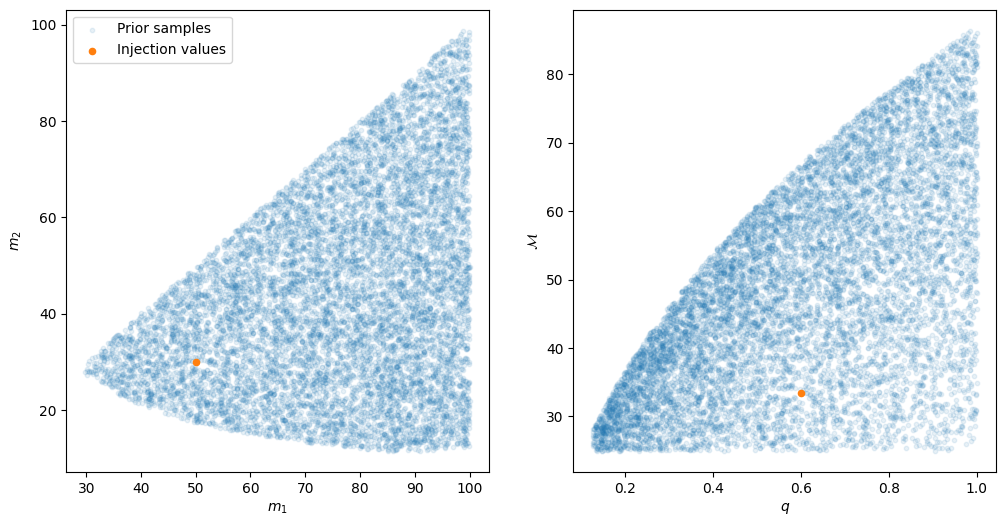

In [22]:
prior_samps = get_component_masses(priors.sample(10000));


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
axes[0].scatter(prior_samps["mass_1"],prior_samps["mass_2"],alpha=0.1, s=10,label = "Prior samples")
axes[0].scatter(injection_parameters["mass_1"],injection_parameters["mass_2"], s=20,label="Injection values")
axes[0].set_xlabel("$m_1$")
axes[0].set_ylabel("$m_2$")
axes[0].legend()
axes[1].scatter(prior_samps["mass_ratio"],prior_samps["chirp_mass"],alpha=0.1, s=10)
axes[1].scatter(injection_parameters["mass_ratio"],injection_parameters["chirp_mass"], s=20)
axes[1].set_xlabel("$q$")
axes[1].set_ylabel("$\\mathcal{M}$");

## The sampler and results

16:12 bilby INFO    : Running for label 'CFCGWA_tutorial', output will be saved to 'outdir'
16:12 bilby INFO    : Using lal version 7.4.1
16:12 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.21;Id: cc61d073d248e45c3c75d3732ee642448f7bc008;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
16:12 bilby INFO    : Using lalsimulation version 5.3.1
16:12 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.21;Id: cc61d073d248e45c3c75d3732ee642448f7bc008;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
16:12 bilby INFO    : Analysis priors:
16:12 bilby INFO    : mass_ratio=bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.125, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None, equal_mass=False)
16:12 bilby INFO    : chirp_mass=bilby.gw.prior.UniformInComponentsChirpMass(minimum=25, maximum=100, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, bounda

1it [00:00, ?it/s]

16:13 bilby INFO    : Written checkpoint file outdir/CFCGWA_tutorial_resume.pickle
16:13 bilby INFO    : Written checkpoint file outdir/CFCGWA_tutorial_resume.pickle
16:13 bilby INFO    : Rejection sampling nested samples to obtain 282 posterior samples
16:13 bilby INFO    : Sampling time: 0:00:28.837619
16:13 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/282 [00:00<?, ?it/s]

16:13 bilby INFO    : Generating sky frame parameters.


  0%|          | 0/282 [00:00<?, ?it/s]

16:13 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/282 [00:00<?, ?it/s]

16:13 bilby INFO    : Summary of results:
nsamples: 282
ln_noise_evidence: -122.912
ln_evidence: -6.758 +/-  0.280
ln_bayes_factor: 116.154 +/-  0.280

16:13 bilby INFO    : Generating waveform figure for H1
16:13 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
16:13 bilby INFO    : Generating waveform figure for L1
16:13 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


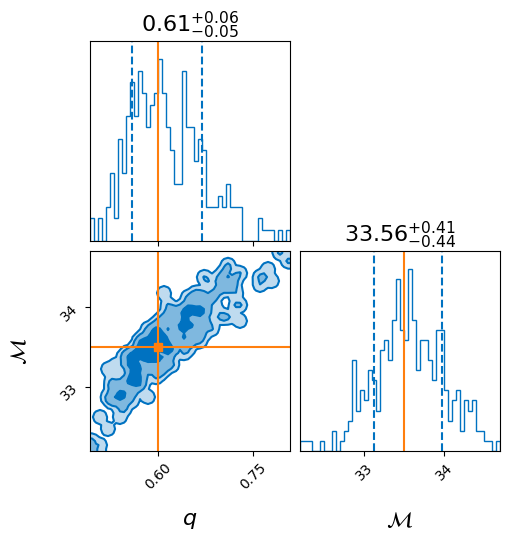

In [23]:
#Run sampler.  In this case we're going to use the `dynesty` sampler which employs nested sampling 
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",# this sampler uses nested sampling   
    nlive=100,#these settings are not sufficient for conversion 
    naccept=5,#these settings are not sufficient for conversion 
    sample="acceptance-walk",
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    clean=True, # Switch this to False if you want to be able to checkpoint and restart your run. 
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    result_class=bilby.gw.result.CBCResult,
)
result.plot_corner(save = False)
result.plot_waveform_posterior(n_samples=1000)
from IPython.display import Image
Image(filename='outdir/CFCGWA_tutorial_H1_waveform.png')

The posterior samples are contained in result.posterior. Each column of samples is distributed according to the one-dimensional marginalized posterior on that parameter. 

The result file is saved as "outdir/label_result.json", where label is a string set at the top of the notebook. If you would like to have the output of a run and compare it to a different one, you can change the label before the run and then load in the result file by uncommenting the first line above

In [24]:
#result = bilby.result.read_in_result(outdir=outdir, label=label) 
result.posterior

,mass_ratio,chirp_mass,luminosity_distance,dec,ra,theta_jn,psi,phase,a_1,a_2,...,chi_2_in_plane,chi_p,cos_tilt_1,cos_tilt_2,redshift,comoving_distance,mass_1_source,mass_2_source,chirp_mass_source,total_mass_source
0,0.494059,32.191377,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,39.061002,19.298428,23.612229,58.359430
1,0.611939,34.173426,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,37.028034,22.658913,25.066053,59.686947
2,0.520316,33.238747,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,39.234557,20.414349,24.380470,59.648906
3,0.505241,32.289426,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,38.715068,19.560421,23.684147,58.275490
4,0.793788,34.702720,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,32.861894,26.085362,25.454288,58.947256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,0.609801,33.576303,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,36.447856,22.225927,24.628066,58.673783
278,0.608873,33.578440,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,36.479293,22.211243,24.629634,58.690536
279,0.592398,33.433748,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,36.848901,21.829229,24.523503,58.678129
280,0.605361,33.517674,2000,-1.2108,1.375,0.4,2.659,1.3,0.0,0.0,...,0.0,0.0,1.0,1.0,0.363335,1466.99092,36.523902,22.110147,24.585062,58.634049


## Questions

Use np.quantile to compute the median and $90\%$ credible intervals on the sampled parameters. Compare these to the injected values. 

Restart the notebook and inject into noise again. What changes?

What happens if you change the prior bounds so they exclude the injection? (Alternatively, shift the injection so it is outside the prior bounds?) 

Can you change the code so that you sample on different parameters? 

What happens if you change the luminosity distance? 

**Restart the kernel each time you rerun the sampler**
